## **Goal**: predict adopted users  
**Definition**: adopted = logged in on 3 separate days in at least one 7-day period  
**Deliverables**: 1-page writeup + a few tables/plots + model/feature importance

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [143]:
users = pd.read_csv("takehome_users_v2.csv")
eng = pd.read_csv("takehome_user_engagement.csv")

In [145]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [149]:
eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [151]:
users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [153]:
eng.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [155]:
print("Users missing object id:",users["object_id"].isna().sum())
print("eng missing user id:",eng["user_id"].isna().sum())
print("eng missing time stamp:",eng["time_stamp"].isna().sum())

Users missing object id: 0
eng missing user id: 0
eng missing time stamp: 0


In [157]:
users["creation_time"] = pd.to_datetime(users["creation_time"],errors = "coerce")
users["last_session_creation_time"] = pd.to_datetime(users["last_session_creation_time"],errors = "coerce")
eng["time_stamp"] = pd.to_datetime(eng["time_stamp"],errors = "coerce")

In [159]:
eng["login_date"] = eng["time_stamp"].dt.normalize()  # midnight of that day


In [161]:
eng_days = eng.drop_duplicates(subset=["user_id", "login_date"]).copy()
print("Raw rows:", len(eng), "Unique user-days:", len(eng_days))


Raw rows: 207917 Unique user-days: 207917


A user is adopted if there exist 3 distinct login dates d1 < d2 < d3 such that:

d3 - d1 <= 6 days (that’s a 7-day window)

This is an efficient way to compute it:

For each user, sort unique login days

Check whether day[i+2] − day[i] ≤ 6 days for any i

In [164]:
def is_adopted_user(user_dates: pd.Series) -> int:
    # user_dates is sorted unique login_date values for one user
    dates = user_dates.sort_values().values
    if len(dates) < 3:
        return 0
    # check 3-day window: i and i+2
    for i in range(len(dates) - 2):
        if (dates[i+2] - dates[i]) <= np.timedelta64(6, "D"):
            return 1
    return 0

In [83]:
adoption = (
    eng_days.groupby("user_id")["login_date"].apply(is_adopted_user).reset_index(name="adopted")
)

print(adoption["adopted"].value_counts(dropna=False))
print(adoption.head())


adopted
0    7221
1    1602
Name: count, dtype: int64
   user_id  adopted
0        1        0
1        2        1
2        3        0
3        4        0
4        5        0


In [85]:
df = users.merge(adoption, left_on="object_id", right_on="user_id", how="left")
df["adopted"] = df["adopted"].fillna(0).astype(int)

print(df["adopted"].value_counts(normalize=True))
df.head()


adopted
0    0.8665
1    0.1335
Name: proportion, dtype: float64


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.398138810,1,0,11,10803.0,1.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1970-01-01 00:00:01.396237504,0,0,1,316.0,2.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1970-01-01 00:00:01.363734892,0,0,94,1525.0,3.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.369210168,0,0,1,5151.0,4.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.358849660,0,0,193,5240.0,5.0,0


In [87]:
# time-based signup features
df["creation_hour"] = df["creation_time"].dt.hour
df["creation_dow"]  = df["creation_time"].dt.dayofweek  # 0=Mon
df["creation_month"] = df["creation_time"].dt.month

# invitation flag
df["was_invited"] = df["invited_by_user_id"].notna().astype(int)

# optional: email domain
df["email_domain"] = df["email"].str.split("@").str[-1].str.lower()


In [89]:
top_domains = df["email_domain"].value_counts().head(20).index
df["email_domain"] = np.where(df["email_domain"].isin(top_domains), df["email_domain"], "other")


In [91]:
org_sizes = df.groupby("org_id")["object_id"].transform("count")
df["org_size"] = org_sizes


In [93]:
def adoption_rate_table(col):
    return df.groupby(col)["adopted"].agg(["mean","count"]).sort_values("mean", ascending=False)

display(adoption_rate_table("creation_source"))
display(adoption_rate_table("opted_in_to_mailing_list"))
display(adoption_rate_table("enabled_for_marketing_drip"))


,mean,count
creation_source,,
SIGNUP_GOOGLE_AUTH,0.167509,1385
GUEST_INVITE,0.166436,2163
SIGNUP,0.140393,2087
ORG_INVITE,0.129995,4254
PERSONAL_PROJECTS,0.077688,2111


,mean,count
opted_in_to_mailing_list,,
1,0.138277,2994
0,0.131912,9006


,mean,count
enabled_for_marketing_drip,,
1,0.137277,1792
0,0.132837,10208


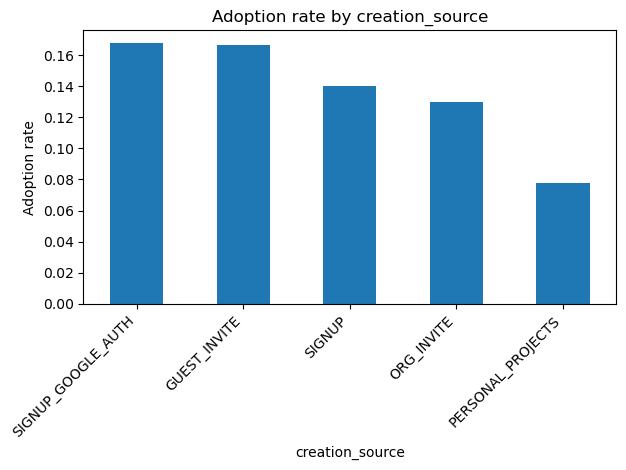

In [99]:
rates = df.groupby("creation_source")["adopted"].mean().sort_values(ascending=False)

plt.figure()
rates.plot(kind="bar")
plt.ylabel("Adoption rate")
plt.title("Adoption rate by creation_source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [105]:
target = "adopted"

feature_cols = [
    "creation_source",
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip",
    "was_invited",
    "org_size",
    "creation_hour",
    "creation_dow",
    "creation_month",
    "email_domain",
]

X = df[feature_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [109]:
cat_cols = ["creation_source", "email_domain"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)


In [111]:
logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)

proba = logreg.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))


ROC-AUC: 0.629251923076923
              precision    recall  f1-score   support

           0       0.91      0.51      0.65      2600
           1       0.18      0.68      0.28       400

    accuracy                           0.53      3000
   macro avg       0.54      0.60      0.47      3000
weighted avg       0.81      0.53      0.60      3000



In [113]:
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("RF ROC-AUC:", roc_auc_score(y_test, rf_proba))


RF ROC-AUC: 0.571151923076923


In [115]:
ohe = logreg.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([cat_feature_names, np.array(num_cols)])

coefs = logreg.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

display(coef_df.head(15))
display(coef_df.tail(15))


,feature,coef
14,email_domain_mumdc.com,1.011935
13,email_domain_luque.com,0.944662
11,email_domain_hotmail.com,0.366449
4,creation_source_SIGNUP_GOOGLE_AUTH,0.228485
0,creation_source_GUEST_INVITE,0.191407
9,email_domain_gmail.com,0.159446
16,email_domain_other,0.129892
26,was_invited,0.123291
3,creation_source_SIGNUP,0.104565
12,email_domain_jourrapide.com,0.043391


,feature,coef
10,email_domain_gustr.com,-0.026617
5,email_domain_cuvox.de,-0.045760
1,creation_source_ORG_INVITE,-0.068115
22,email_domain_yahoo.com,-0.132057
18,email_domain_rerwl.com,-0.176233
8,email_domain_fukqx.com,-0.178192
6,email_domain_difbq.com,-0.197659
19,email_domain_sjrhj.com,-0.198828
23,email_domain_ynsbd.com,-0.199067
7,email_domain_fqoyc.com,-0.211586


In [117]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    logreg, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)


,feature,importance_mean,importance_std
4,org_size,0.055816,0.010013
0,creation_source,0.054871,0.012691
8,email_domain,0.024964,0.006440
7,creation_month,0.007642,0.003967
3,was_invited,0.001912,0.001968
1,opted_in_to_mailing_list,0.001023,0.000493
6,creation_dow,-0.000069,0.000051
5,creation_hour,-0.000103,0.000550
2,enabled_for_marketing_drip,-0.000179,0.000430


In [119]:
print(df["adopted"].value_counts(normalize=True))

print(adoption_rate_table("creation_source"))

adopted
0    0.8665
1    0.1335
Name: proportion, dtype: float64
                        mean  count
creation_source                    
SIGNUP_GOOGLE_AUTH  0.167509   1385
GUEST_INVITE        0.166436   2163
SIGNUP              0.140393   2087
ORG_INVITE          0.129995   4254
PERSONAL_PROJECTS   0.077688   2111


In [121]:
df.groupby("opted_in_to_mailing_list")["adopted"].agg(["mean", "count"])


,mean,count
opted_in_to_mailing_list,,
0,0.131912,9006
1,0.138277,2994


In [123]:
df.groupby("enabled_for_marketing_drip")["adopted"].agg(["mean", "count"])


,mean,count
enabled_for_marketing_drip,,
0,0.132837,10208
1,0.137277,1792


In [125]:
df.groupby("was_invited")["adopted"].agg(["mean", "count"])


,mean,count
was_invited,,
0,0.123410,5583
1,0.142278,6417


In [166]:
df["org_size_bin"] = pd.cut(
    df["org_size"],
    bins=[0, 1, 5, 20, 100, np.inf],
    labels=["solo", "small", "medium", "large", "very_large"],
    include_lowest=True
)

df.groupby("org_size_bin",observed = True)["adopted"].agg(["mean", "count"])


,mean,count
org_size_bin,,
small,0.000000,2
medium,0.165156,2979
large,0.133361,7326
very_large,0.078559,1693
